# Testing the Force Components of CONTIGO

- [x] Gravatation Potential 
- [x] Third body acceleration
- [x] [Constants](https://ssd.jpl.nasa.gov/doc/Park.2021.AJ.DE440.pdf)

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.integrate import cumulative_simpson

In [15]:
import contigo.config as config

In [16]:
print(config.DATA_DIR)
print(config.state)

D:\GitHub\contigo_edr\contigo\data
{'gmat_loaded': True, 'gmatpy': <module 'gmatpy' from 'C:\\Users/murph/GMAT_R2025a/bin\\gmatpy\\__init__.py'>, 'kernel_downloaded': True, 'pot_coef_loaded': True, 'pot_file': 'EIGEN-2.gfc', 'pot_clm': array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.84165816e-04, -1.39274045e-10,  2.43930492e-06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.21573246e-09,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         6.89288278e-10, -7.83724359e-09,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.47313695e-09, -7.36524867e-10, -8.95663870e-09]],
      s

In [17]:
from contigo.forces.grav_pot import GravPot
from contigo.forces.third_body_acc import ThirdBodyAcc
from contigo.forces.srp_acc import SRPGMATAcc

In [18]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")
sw_o = pd.read_hdf("./data/ore_d.hdf")

efd_e = pd.read_hdf("./data/efd_esa_pod.hdf")
gmat_e = pd.read_hdf("./data/efd_gmat_ekf.hdf")

nmax = 100

spos = sw_e[['x','y','z']].to_numpy()
stime = sw_e['DateTime']
x = sw_e['x'].to_numpy()
y = sw_e['y'].to_numpy()
z = sw_e['z'].to_numpy()

lat = np.arctan2(z,np.sqrt(x*x+y*y))
lon = np.arctan2(y,x)

r = np.sqrt(x*x+y*y+z*z)

### Get the CONTIGO Gravatational Potential

In [19]:
gp_cont = GravPot(r=r,lat=lat,lon=lon,pot_file=r'EIGEN-2.gfc',lmax=100)
gp_cont.calc_pot()

INFO:Loading Potential coeffecients from current state which used EIGEN-2.gfc.


### Get the CONTIGO Third Body Acceleration from the Sun and Moon

In [20]:
tba_cont = ThirdBodyAcc(spos=spos,stime=stime,body=['SUN','MOON'],scale='GPS')  
tba_cont.calc_tba()

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


loading kernels


### Get CONTIGO SRP Acceleration Via GMAT

In [21]:
sc_state = sw_e[['x','y','z','vx','vy','vz']].to_numpy()
sc_time = sw_e['DateTime'].to_numpy()

scr = np.zeros_like(sc_state[:,0])
scm = np.zeros_like(sc_state[:,0])
sca = np.zeros_like(sc_state[:,0])
scr[:] = 1.8
scm[:] = 4.3e+02
sca[:] = 1

x = SRPGMATAcc(sc_state=sc_state, sc_time=sc_time, 
               sc_cr=scr, sc_srparea=sca, sc_mass=scm,
               apistartup="api_startup_file.txt",
               gmat_install="C:/Users/murph/GMAT_R2025a/")

x.calc_srp()

INFO:GMAT API already setup.


In [22]:
srp_f = x.srp_acc_ecef
srp_i = x.srp_acc_eci

gmat_srp = sw_e[['srp_x', 'srp_y', 'srp_z']].to_numpy()

print(np.linalg.norm(srp_f,axis=1)[-40::10])
print(np.linalg.norm(srp_i,axis=1)[-40::10])
print(np.linalg.norm(gmat_srp,axis=1)[-40::10])


print(np.allclose(np.linalg.norm(srp_f,axis=1),np.linalg.norm(srp_i,axis=1)))
print(np.allclose(srp_i,gmat_srp))

[1.97193947e-11 1.97193342e-11 1.97192641e-11 1.97191854e-11]
[1.97193947e-11 1.97193342e-11 1.97192641e-11 1.97191854e-11]
[1.97193947e-11 1.97193342e-11 1.97192641e-11 1.97191854e-11]
True
True


### Compare CONTIGO Values to Orekit Values

Note that Orekit is in meters and CONTIGO is in Km's

In [23]:
print('GP all close - ', np.allclose(sw_o['earth_gp'].to_numpy(),gp_cont.gravpot*1000**2))
print('Sun TBA all close - ', np.allclose(sw_o[['ecef_sn_ax','ecef_sn_ay','ecef_sn_az']], 
                  tba_cont.bd_acc[0,:,:]*1000))
print('Moon TBA all close - ',np.allclose(sw_o[['ecef_mn_ax','ecef_mn_ay','ecef_mn_az']], 
                  tba_cont.bd_acc[1,:,:]*1000))


GP all close -  True
Sun TBA all close -  True
Moon TBA all close -  True


## Derive/Plot Effective Density

In [24]:
# Sun and Moon Acceleratios Derived from Orekit
# Positions in ECEF
sn_af = sw_o[['ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az']].to_numpy()
mn_af = sw_o[['ecef_mn_ax', 'ecef_mn_ay', 'ecef_mn_az']].to_numpy()

sn_af = tba_cont.bd_acc[0,:,:]*1000.
mn_af = tba_cont.bd_acc[1,:,:]*1000.

edr_pot = gp_cont.gravpot*1000**2

In [25]:
print(sn_af[0,:])
print(mn_af[0,:])
print(srp_f[0,:]*1000)

[-9.00593868e-08  2.80000065e-07  9.67684671e-09]
[-1.81861563e-07  7.29546172e-07  5.87371096e-08]
[1.81782188e-08 3.51030730e-10 7.69296643e-09]


In [26]:
int_sec = (pd.DatetimeIndex(sw_e['DateTime']).to_julian_date()*86400.).to_numpy()
int_sec = int_sec-int_sec.min()

ecef_v = sw_e[['vx','vy','vz']].to_numpy()*1000
ecef_r = sw_e[['x','y','z']].to_numpy()*1000
ecef_xy2 = (sw_e['x'].to_numpy()*1000)**2+(sw_e['y'].to_numpy()*1000)**2
ecef_v2 = (ecef_v*ecef_v).sum(axis=1)
w2 = 5.3174941173225e-09

eci_v = sw_e[['eci_vx','eci_vy','eci_vz']].to_numpy()*1000
srp_a = sw_e[['srp_x','srp_y','srp_z']].to_numpy()*1000
srp_fms =  srp_f*1000.

a1 = (sn_af*ecef_v).sum(axis=1)
a2 = (mn_af*ecef_v).sum(axis=1)
a3 = (srp_fms*ecef_v).sum(axis=1) # this is a fudge factor that we can fix

# denomenator
B = (3.5)*(1.1)/(4.3e+02)
ecef_v3 = np.linalg.norm(ecef_v, axis=1)**3

In [27]:
rolling = int(90*60/10)

edr = ecef_v2/2. - w2*ecef_xy2/2. - edr_pot - \
      cumulative_trapezoid(a1, int_sec, initial=0) - \
      cumulative_trapezoid(a2, int_sec,initial=0) - \
      cumulative_trapezoid(a3, int_sec,initial=0) # for exact comparison to orekit
edr = edr - ecef_v2[0]/2. - w2*ecef_xy2[0]/2. - edr_pot[0]

denom = B*cumulative_trapezoid(ecef_v3, int_sec,initial=0)

cont_edr = pd.DataFrame({'edr':edr, 'denom':denom})
cont_edr['DateTime'] = sw_e['DateTime']
cont_edr['edr_rolling'] = cont_edr['edr'].rolling(rolling).mean()  

Contigo and Orekit all close - True
-116.0620853983725
-116.06208539837247


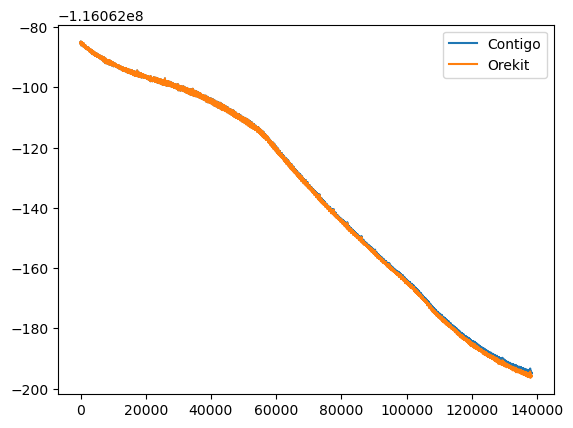

In [28]:
ax = cont_edr['edr'].plot(label='Contigo')
sw_o['edr'].plot(ax=ax, label='Orekit')
ax.legend()

ac = np.allclose(cont_edr['edr'].to_numpy(),sw_o['edr'].to_numpy())

print(f'Contigo and Orekit all close - {ac}')
print(cont_edr['edr'][0]/1000**2)
print(sw_o['edr'][0]/1000**2)


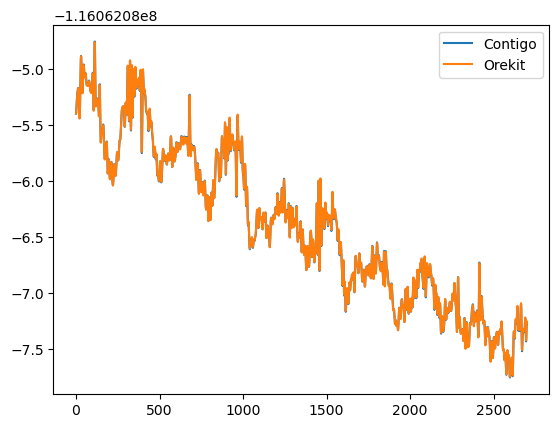

In [29]:
intv = 5*90*60/10

ax = cont_edr.loc[0:intv,'edr'].plot(label='Contigo')
sw_o.loc[0:intv,'edr'].plot(ax=ax, label='Orekit')
ax.legend()

In [30]:
ti = int(90*60/10.) 
cont_efd = pd.DataFrame()
cont_efd['efd'] = -2*(cont_edr['edr_rolling'].shift(ti)-cont_edr['edr_rolling'])/(cont_edr['denom'].shift(ti)-cont_edr['denom']) 
cont_efd['efd'] = cont_efd['efd']*(1000**3)
cont_efd['DateTime'] = cont_edr['DateTime']

<Axes: xlabel='DateTime'>

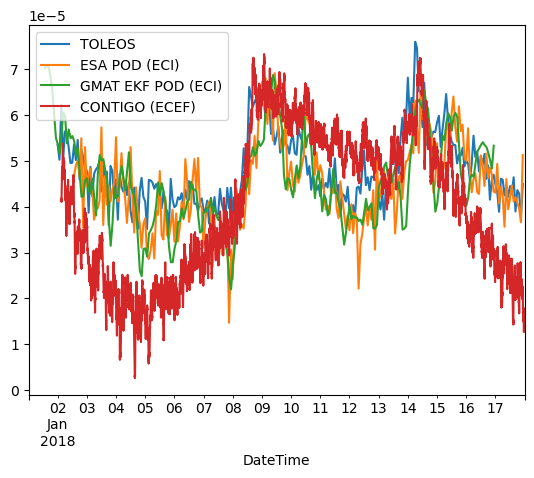

In [31]:
ax = efd_e.plot(x='DateTime',y=['tol_efd','efd_1'],label=['TOLEOS', 'ESA POD (ECI)'])
gmat_e.plot(x='DateTime',y='efd_0',label='GMAT EKF POD (ECI)', ax=ax)
cont_efd.plot(x='DateTime', y='efd', label='CONTIGO (ECEF)', ax=ax)

### Testing SRP a bit more

In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
from contigo.forces import srp_utils
srp_utils.setup_gmat("api_startup_file.txt","C:/Users/murph/GMAT_R2025a/")


INFO:GMAT API already setup.


In [35]:
import contigo.config as config
from contigo.forces.srp_acc import SRPGMATAcc

In [36]:
config.state['gmat_loaded']

True

In [37]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")
sc_state = sw_e[['x','y','z','vx','vy','vz']].to_numpy()
sc_time = sw_e['DateTime'].to_numpy()

scr = np.zeros_like(sc_state[:,0])
scm = np.zeros_like(sc_state[:,0])
sca = np.zeros_like(sc_state[:,0])
scr[:] = 1.8
scm[:] = 4.3e+02
sca[:] = 1


In [38]:
x = SRPGMATAcc(sc_state=sc_state, sc_time=sc_time, 
               sc_cr=scr, sc_srparea=sca, sc_mass=scm,
               apistartup="api_startup_file.txt",
               gmat_install="C:/Users/murph/GMAT_R2025a/")

INFO:GMAT API already setup.


In [39]:
x.calc_srp()
srp_ecef, srp_eci = x.get_all_acc()

In [40]:
srp_f = np.array(srp_ecef)
srp_i = np.array(srp_eci)

gmat_srp = sw_e[['srp_x', 'srp_y', 'srp_z']].to_numpy()

print(np.linalg.norm(srp_f,axis=1)[-40::10])
print(np.linalg.norm(srp_i,axis=1)[-40::10])
print(np.linalg.norm(gmat_srp,axis=1)[-40::10])


print(np.allclose(np.linalg.norm(srp_f,axis=1),np.linalg.norm(srp_i,axis=1)))
print(np.allclose(srp_i,gmat_srp))

[1.97193947e-11 1.97193342e-11 1.97192641e-11 1.97191854e-11]
[1.97193947e-11 1.97193342e-11 1.97192641e-11 1.97191854e-11]
[1.97193947e-11 1.97193342e-11 1.97192641e-11 1.97191854e-11]
True
True


### Test Changing Mass, Cr, and Area

In [41]:
scr[::10] = scr[::10]*10
scr[::10] = scr[::10]*10
x = SRPGMATAcc(sc_state=sc_state, sc_time=sc_time, 
               sc_cr=scr, sc_srparea=sca, sc_mass=scm,
               apistartup="api_startup_file.txt",
               gmat_install="C:/Users/murph/GMAT_R2025a/")
x.calc_srp()
xa = x.get_ecef_acc()

scm[::10] = scm[::10]*10
y = SRPGMATAcc(sc_state=sc_state, sc_time=sc_time, 
               sc_cr=scr, sc_srparea=sca, sc_mass=scm,
               apistartup="api_startup_file.txt",
               gmat_install="C:/Users/murph/GMAT_R2025a/")
y.calc_srp()
ya = x.get_ecef_acc()


sca[::10] = sca[::10]*10
z = SRPGMATAcc(sc_state=sc_state, sc_time=sc_time, 
               sc_cr=scr, sc_srparea=sca, sc_mass=scm,
               apistartup="api_startup_file.txt",
               gmat_install="C:/Users/murph/GMAT_R2025a/")
z.calc_srp()
za = x.get_ecef_acc()

INFO:GMAT API already setup.
INFO:GMAT API already setup.
INFO:GMAT API already setup.


In [42]:
print(srp_f[10,-3:])
print(xa[10,:])
print(ya[10,:])
print(za[10,:])


[1.81804021e-11 2.18895003e-13 7.69287413e-12]
[1.81804021e-09 2.18895003e-11 7.69287413e-10]
[1.81804021e-09 2.18895003e-11 7.69287413e-10]
[1.81804021e-09 2.18895003e-11 7.69287413e-10]
